In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates
import plotly.express as px

from sklearn import linear_model
import pymannkendall as mk

In [2]:
# datana = data.resample("1d").asfreq()

datana = pd.read_csv("test.csv")
datana['MESSZEITPUNKT'] = pd.to_datetime(datana['MESSZEITPUNKT'], format='%Y-%m-%d')
datana = datana.set_index('MESSZEITPUNKT')
# Daten als Serie
#datana = datana["WERT_UNTER_GELAENDE"]


#print(datana.head())
#fig, ax = plt.subplots(figsize=(12, 8))
#ax.plot(datana, '.')
#ax.plot(datana.index, trend_line)
#ax.legend(['datana', 'trend line'])

In [3]:
data = datana.dropna()

#print(data.head())
#fig, ax = plt.subplots(figsize=(12, 8))
#ax.plot(data, '.')

In [4]:
# Grimm-Strele aus linearer Regression
add = data["WERT_UNTER_GELAENDE"]
alle = data.copy()
alle["pred"] = "Messung"

# Lineare Regression
x = (add.index - add.index[0]).days.values.reshape(-1, 1) / 365 # /365 ändert die Zeitwerte von Tag auf Jahr
y = add.values                                                  # Die WERT_UNTER_GELAENDE Werte sind in cm
a = linear_model.LinearRegression().fit(x, y)

z = 1
Messstellen = pd.DataFrame(columns=["MKZ",
                                    "Trend Grimm Strele",
                                    "Anstieg Regression",
                                    "Spanne",
                                    "Anzahl Werte",
                                    "Messturnus [Tage] geschätzt"]
                          )
Messstellen.loc[0,"MKZ"] = 1
# Berechnung Grimm Strele Trendwerte und Anfügen an Dataframe
Messstellen.loc[(Messstellen["MKZ"]==z, "Trend Grimm Strele")] = -a.coef_ / (y.max()-y.min()) *100 # Anstieg in cm/a / Spannweite der cm --> Grimm-Strele Test
Messstellen.loc[(Messstellen["MKZ"]==z, "Anstieg Regression")] = -a.coef_  # Anstieg in cm/a
Messstellen.loc[(Messstellen["MKZ"]==z, "Spanne")] = y.max()-y.min() # Spannweite der cm
Messstellen.loc[(Messstellen["MKZ"]==z, "Anzahl Werte")] = len(y) # Anzahl der Werte
Turnus = np.median(np.diff([xss for xs in x for xss in xs]))*365
Messstellen.loc[(Messstellen["MKZ"]==z, "Messturnus [Tage] geschätzt")] = Turnus # Anzahl der Werte

pred = alle.iloc[0:0,].copy()
# print(pred)
pred.loc[add.index[0],"WERT_UNTER_GELAENDE"] = a.predict([[x.min()]])[0]
pred.loc[add.index[0],"pred"] = "Trend lineares Modell"

pred.loc[add.index[-1],"WERT_UNTER_GELAENDE"] = a.predict([[x.max()]])[0]
pred.loc[add.index[-1],"pred"] = "Trend lineares Modell"

alle = pd.concat([alle, pred])
# alle

print(Messstellen)

  MKZ Trend Grimm Strele Anstieg Regression Spanne Anzahl Werte  \
0   1          -0.631078          -0.530105   84.0         2829   

  Messturnus [Tage] geschätzt  
0                         1.0  


In [5]:
# Grimm-Strele aus PyMannKendal ohne NA-Werte
res = mk.original_test(data)
trend_line = np.arange(len(data)) * res.slope + res.intercept

#st.write(resutl1.slope*365)

trend_line

pred2 = alle.iloc[0:0,].copy()
# print(pred2)

pred.loc[data.index[0],"WERT_UNTER_GELAENDE"] = trend_line[0]
pred.loc[data.index[0],"pred"] = "Trend pymk"

pred.loc[data.index[-1],"WERT_UNTER_GELAENDE"] = trend_line[-1]
pred.loc[data.index[-1],"pred"] = "Trend pymk"

alle = pd.concat([alle, pred])
# alle

In [6]:
# Grimm-Strele aus PyMannKendal mit NA-Werten
res = mk.original_test(datana)
trend_line = np.arange(len(datana)) * res.slope + res.intercept

#st.write(resutl1.slope*365)

trend_line

pred2 = alle.iloc[0:0,].copy()
# print(pred2)

pred.loc[datana.index[0],"WERT_UNTER_GELAENDE"] = trend_line[0]
pred.loc[datana.index[0],"pred"] = "Trend pymk mit NA"

pred.loc[datana.index[-1],"WERT_UNTER_GELAENDE"] = trend_line[-1]
pred.loc[datana.index[-1],"pred"] = "Trend pymk mit NA"

alle = pd.concat([alle, pred])
# alle

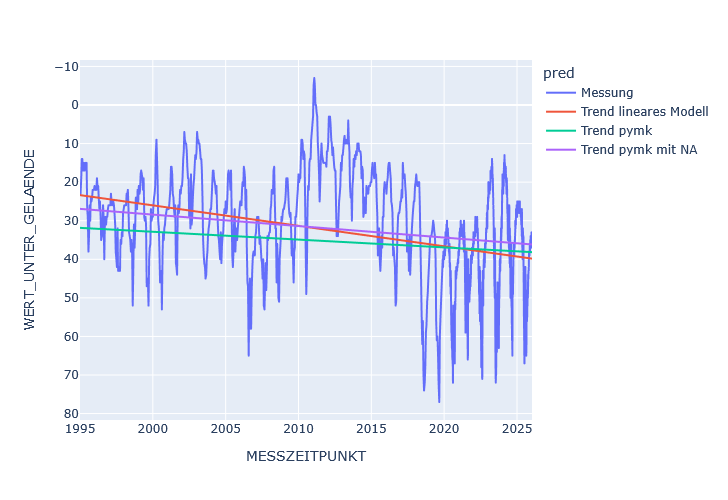

In [7]:
fig = px.line(alle,
              y="WERT_UNTER_GELAENDE",
              color = "pred",
              height=500
              )
fig['layout']['yaxis']['autorange'] = "reversed"
fig

In [8]:
monthly = datana.resample("1MS").mean()

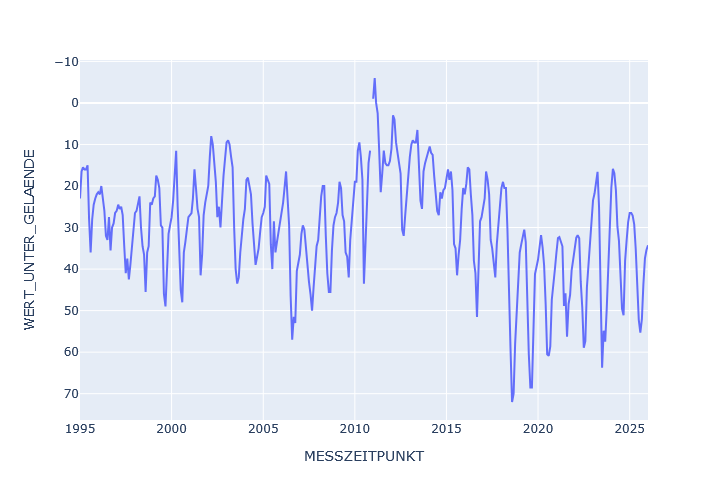

In [9]:
fig = px.line(monthly,
              y="WERT_UNTER_GELAENDE",
              #color = "pred",
              height=500
              )
fig['layout']['yaxis']['autorange'] = "reversed"
fig

In [10]:
# Grimm-Strele aus PyMannKendal mit NA-Werten monatlich resampled
res = mk.original_test(monthly)
trend_line = np.arange(len(monthly)) * res.slope + res.intercept

pred2 = alle.iloc[0:0,].copy()
# print(pred2)

pred.loc[datana.index[0],"WERT_UNTER_GELAENDE"] = trend_line[0]
pred.loc[datana.index[0],"pred"] = "Trend pymk mit NA.resample('1MS')"

pred.loc[datana.index[-1],"WERT_UNTER_GELAENDE"] = trend_line[-1]
pred.loc[datana.index[-1],"pred"] = "Trend pymk mit NA.resample('1MS')"

alle = pd.concat([alle, pred])
# alle

In [11]:
# Grimm-Strele aus linearer Regression, monatlich resampled
add = monthly["WERT_UNTER_GELAENDE"].dropna()

# Lineare Regression
x = (add.index - add.index[0]).days.values.reshape(-1, 1) / 365 # /365 ändert die Zeitwerte von Tag auf Jahr
y = add.values                                                  # Die WERT_UNTER_GELAENDE Werte sind in cm
a = linear_model.LinearRegression().fit(x, y)

z = 1
Messstellen = pd.DataFrame(columns=["MKZ",
                                    "Trend Grimm Strele",
                                    "Anstieg Regression",
                                    "Spanne",
                                    "Anzahl Werte",
                                    "Messturnus [Tage] geschätzt"]
                          )
Messstellen.loc[0,"MKZ"] = 1
# Berechnung Grimm Strele Trendwerte und Anfügen an Dataframe
Messstellen.loc[(Messstellen["MKZ"]==z, "Trend Grimm Strele")] = -a.coef_ / (y.max()-y.min()) *100 # Anstieg in cm/a / Spannweite der cm --> Grimm-Strele Test
Messstellen.loc[(Messstellen["MKZ"]==z, "Anstieg Regression")] = -a.coef_  # Anstieg in cm/a
Messstellen.loc[(Messstellen["MKZ"]==z, "Spanne")] = y.max()-y.min() # Spannweite der cm
Messstellen.loc[(Messstellen["MKZ"]==z, "Anzahl Werte")] = len(y) # Anzahl der Werte
Turnus = np.median(np.diff([xss for xs in x for xss in xs]))*365
Messstellen.loc[(Messstellen["MKZ"]==z, "Messturnus [Tage] geschätzt")] = Turnus # Anzahl der Werte

pred = alle.iloc[0:0,].copy()
# print(pred)
pred.loc[add.index[0],"WERT_UNTER_GELAENDE"] = a.predict([[x.min()]])[0]
pred.loc[add.index[0],"pred"] = "Trend lineares Modell.resample('1MS')"

pred.loc[add.index[-1],"WERT_UNTER_GELAENDE"] = a.predict([[x.max()]])[0]
pred.loc[add.index[-1],"pred"] = "Trend lineares Modell.resample('1MS')"

alle = pd.concat([alle, pred])
# alle

print(Messstellen)

  MKZ Trend Grimm Strele Anstieg Regression Spanne Anzahl Werte  \
0   1          -0.517502          -0.403652   78.0          372   

  Messturnus [Tage] geschätzt  
0                        31.0  


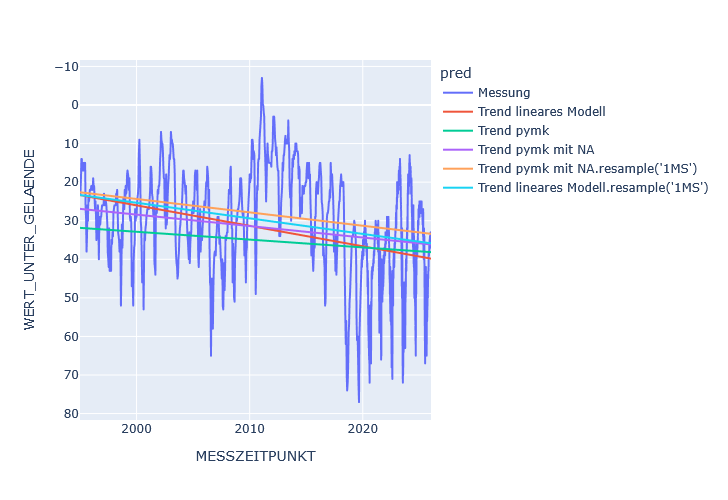

In [12]:
fig = px.line(alle,
              y="WERT_UNTER_GELAENDE",
              color = "pred",
              height=500
              )
fig['layout']['yaxis']['autorange'] = "reversed"
fig